In [1]:
from netCDF4 import Dataset

In [3]:
from AutoEncoder_Experiment import *
import sys, jax
from datetime import datetime
jax.config.update("jax_enable_x64", True)

In [4]:
#JSON is arg
json_fn = 'Sigmoids_Dropout3.json'
#To be added to json
num_rmsd_epochs = 100 #Initial Run
nm_cutoff = 0.1 #target rmsd in nm
rmsd_cutoff = 1500 #num epochs to force training to summation
num_move_ave = 50 #number of previous points for moving average calculations
potential_threshold = 1e-3 #Target Potential NSD tolerance
cutoff_epoch = 30000 #maximum number of epochs of training

In [5]:
#Init Experiment
experiment = AutoEncoder_Experiment(json_fn)

(8000, 1926) (2000, 1926)
### MODEL TYPE = AE_Sigmoid_Dropout ###
Sigmoid_Dropout_AutoEncoder(
    # attributes
    input_size = 1926
    hidden_layers = [1926, 1926, 1926]
    n_latents = 7
    dropout_rates = [0.3, 0.3, 0.3]
)
INITIALIZATION COMPLETE


In [6]:
start = datetime.now()

In [7]:
experiment.train_nepochs_on_rmsd(30)
walltime = datetime.now() - start
print(f'Walltime per epoch was {walltime}')
#experiment.save_loss_data()
#experiment.write_model_to_ckpt()
begin_scaling_epoch = experiment.epoch


epoch 0 atom_rmsd_nm 1.9275E+00 1.9276E+00 dPotEnr 4.4544E+21 4.4701E+21 Summation 2.7259E+01 2.7260E+01 L=0.0000E+00
epoch 1 atom_rmsd_nm 1.8574E+00 1.8574E+00 dPotEnr 1.4000E+30 1.4031E+30 Summation 2.6267E+01 2.6268E+01 L=0.0000E+00
epoch 2 atom_rmsd_nm 1.7887E+00 1.7887E+00 dPotEnr 1.4020E+21 1.4031E+21 Summation 2.5296E+01 2.5297E+01 L=0.0000E+00
epoch 3 atom_rmsd_nm 1.7211E+00 1.7211E+00 dPotEnr 5.2212E+28 5.2309E+28 Summation 2.4340E+01 2.4340E+01 L=0.0000E+00
epoch 4 atom_rmsd_nm 1.6542E+00 1.6543E+00 dPotEnr 4.4851E+21 4.4894E+21 Summation 2.3394E+01 2.3395E+01 L=0.0000E+00
epoch 5 atom_rmsd_nm 1.5879E+00 1.5880E+00 dPotEnr 1.0537E+25 1.0569E+25 Summation 2.2457E+01 2.2458E+01 L=0.0000E+00
epoch 6 atom_rmsd_nm 1.5220E+00 1.5221E+00 dPotEnr 4.2770E+22 4.2705E+22 Summation 2.1525E+01 2.1526E+01 L=0.0000E+00
epoch 7 atom_rmsd_nm 1.4564E+00 1.4564E+00 dPotEnr 4.9019E+27 4.8583E+27 Summation 2.0596E+01 2.0597E+01 L=0.0000E+00
epoch 8 atom_rmsd_nm 1.3908E+00 1.3909E+00 dPotEnr INF I

In [ ]:
end_scaling_epoch = experiment.train_scaling_potential(cutoff_epoch, freq=5)
#freq=number of epochs before reevaluate pot rmsd ratio,  this should be low as the dataset is large (many batches per epoch)
print('END SCALING POTENTIAL')
walltime = datetime.now() - start
print(f'Walltime per epoch was {walltime}')
experiment.save_loss_data()
experiment.write_model_to_ckpt()

epoch 30 atom_rmsd_nm 1.6721E-01 1.6750E-01 dPotEnr 4.3651E+14 4.3621E+14 Summation 5.3374E-01 5.3458E-01 L=4.4923E-22
epoch 31 atom_rmsd_nm 1.6715E-01 1.6744E-01 dPotEnr 5.1418E+14 5.1373E+14 Summation 5.3354E-01 5.3438E-01 L=4.4923E-22
epoch 32 atom_rmsd_nm 1.6707E-01 1.6737E-01 dPotEnr 5.6094E+14 5.6027E+14 Summation 5.3331E-01 5.3415E-01 L=4.4923E-22


In [ ]:
experiment.train_summation(1e-1, 10, cutoff_epoch)
print('END TRAINING')
walltime = datetime.now() - start
print(f'Walltime was {walltime}')
#experiment.save_loss_data()
#experiment.write_model_to_ckpt()

In [9]:
rng_init = jax.random.PRNGKey(54)
rng, key = jax.random.split(rng_init)
recon, latents = experiment.state.apply_fn({'params':experiment.state.params}, experiment.test_data, rng)

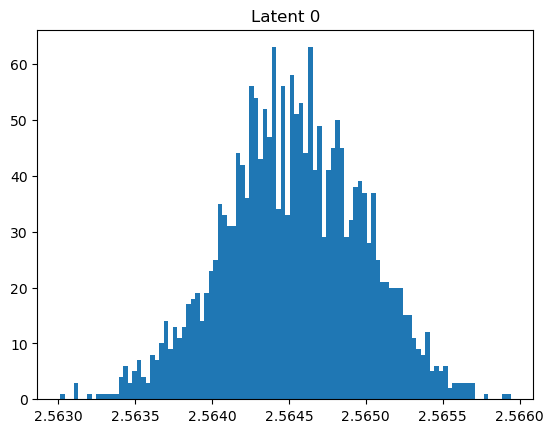

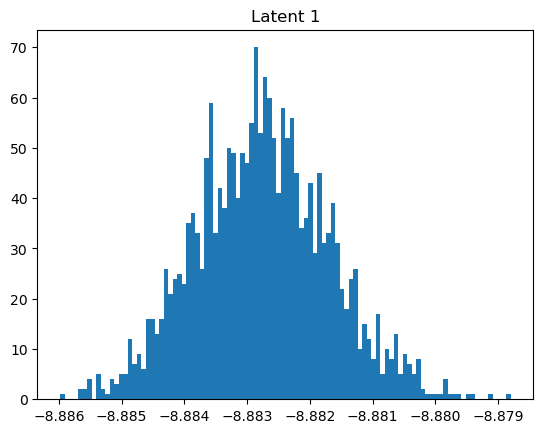

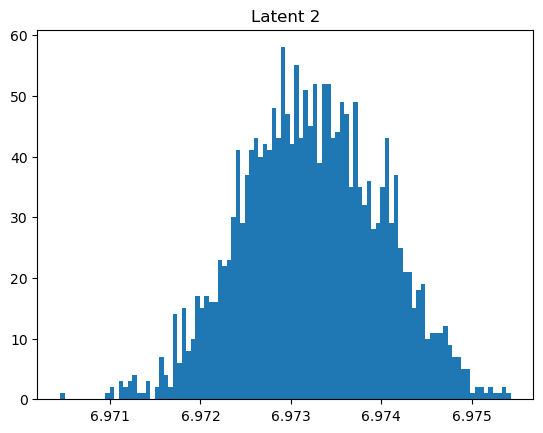

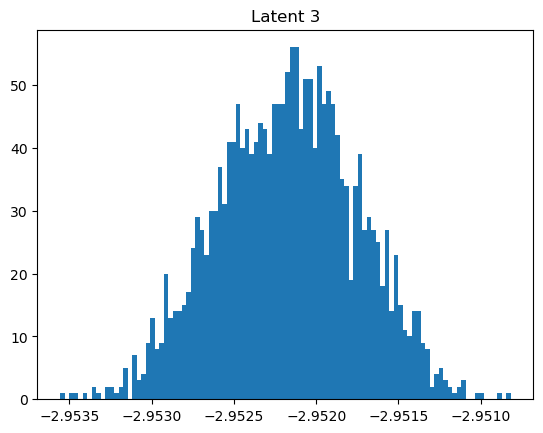

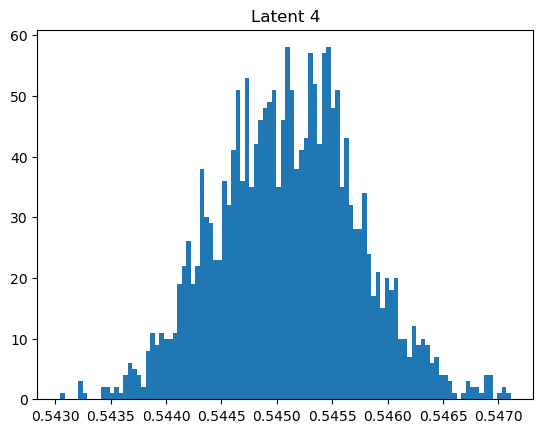

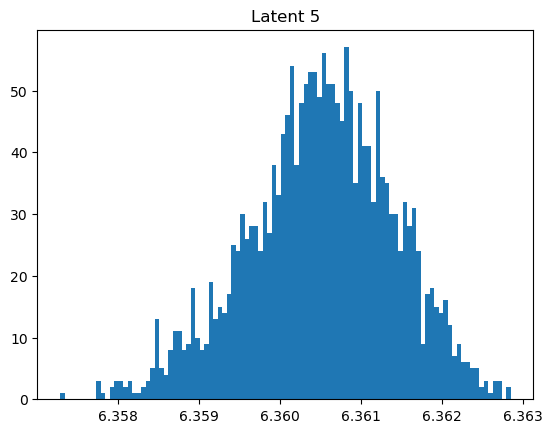

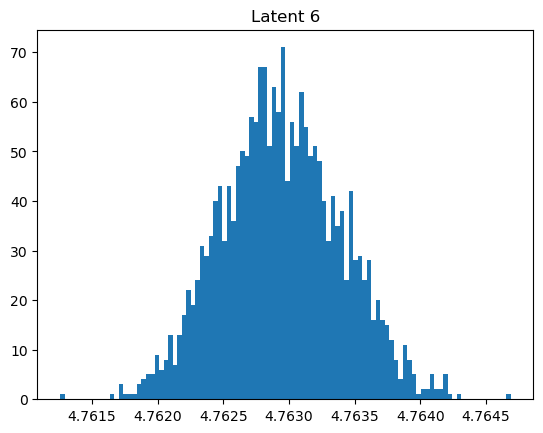

In [10]:
for i in range(latents.shape[-1]):
    plt.clf()
    plt.title(f'Latent {i}')
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

In [11]:
from sklearn.mixture import GaussianMixture

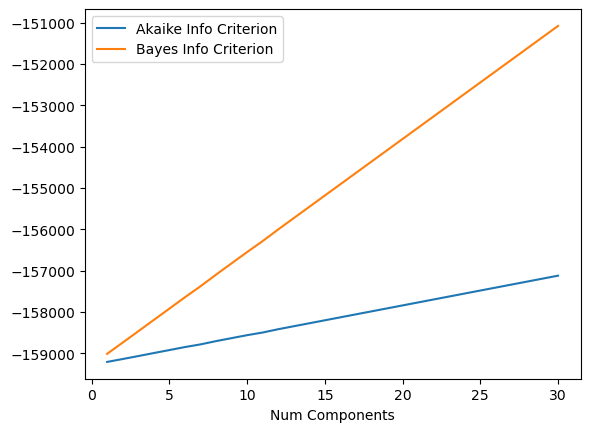

In [12]:
ics = []
for i in range(1, 31):
    X = np.array(latents)
    MM = GaussianMixture(n_components=i).fit(X)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()

In [15]:
X = np.array(latents)
MM = GaussianMixture(n_components=1).fit(X) #chosen based on above graph
samples = MM.sample(1800)[0]

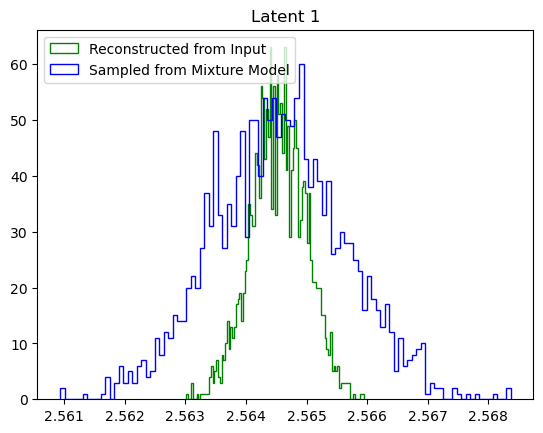

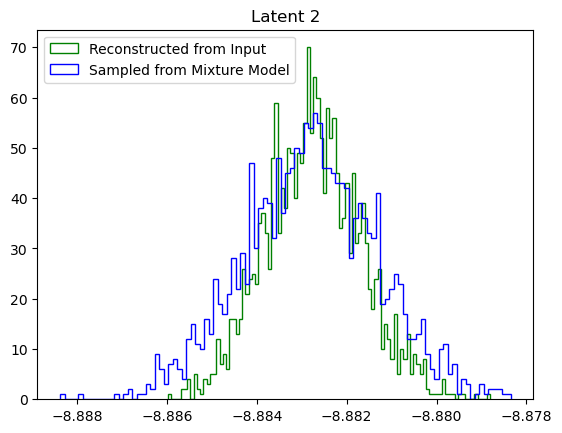

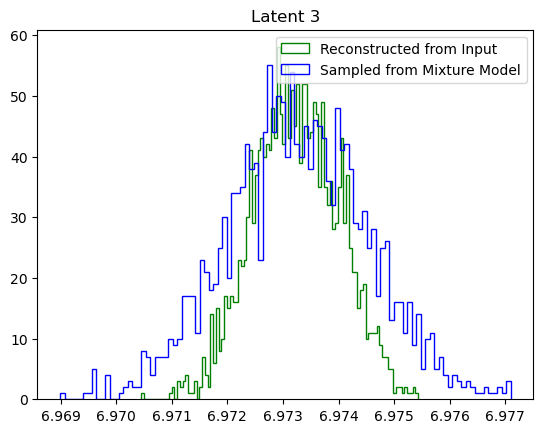

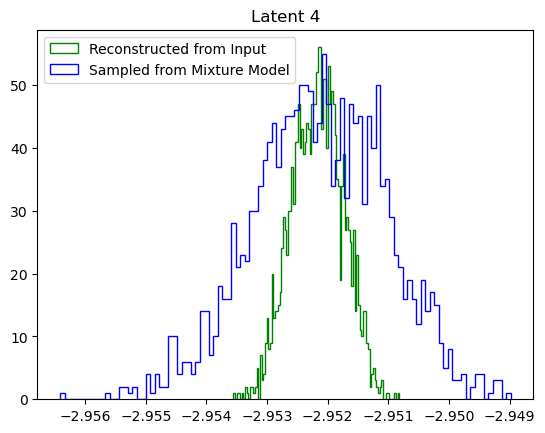

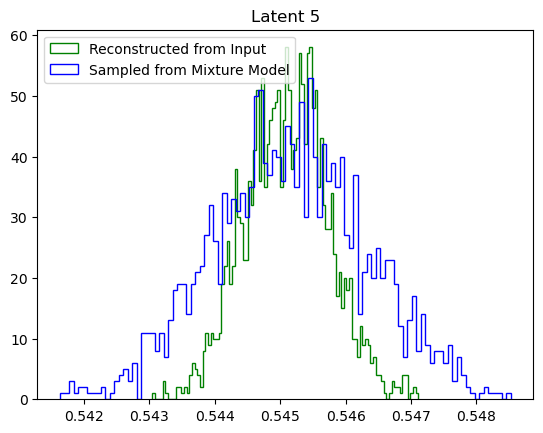

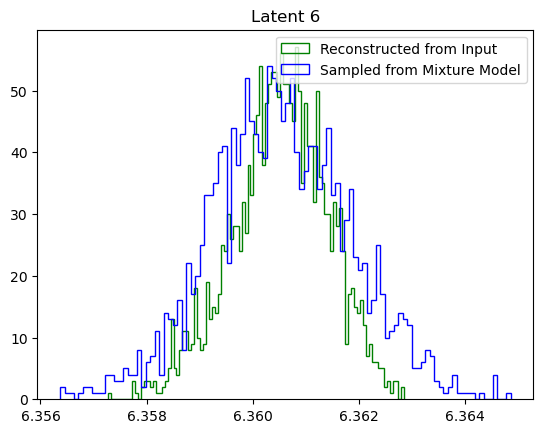

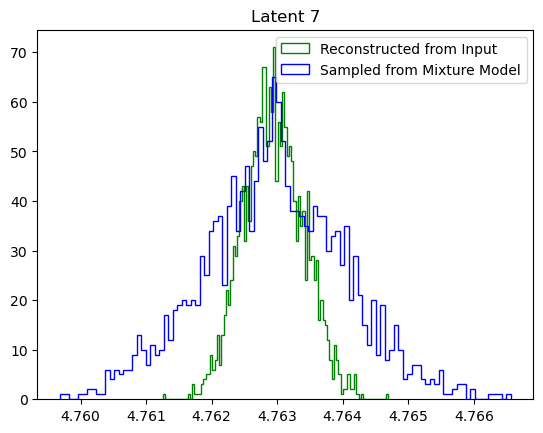

In [16]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:,i], bins=100, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=100, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

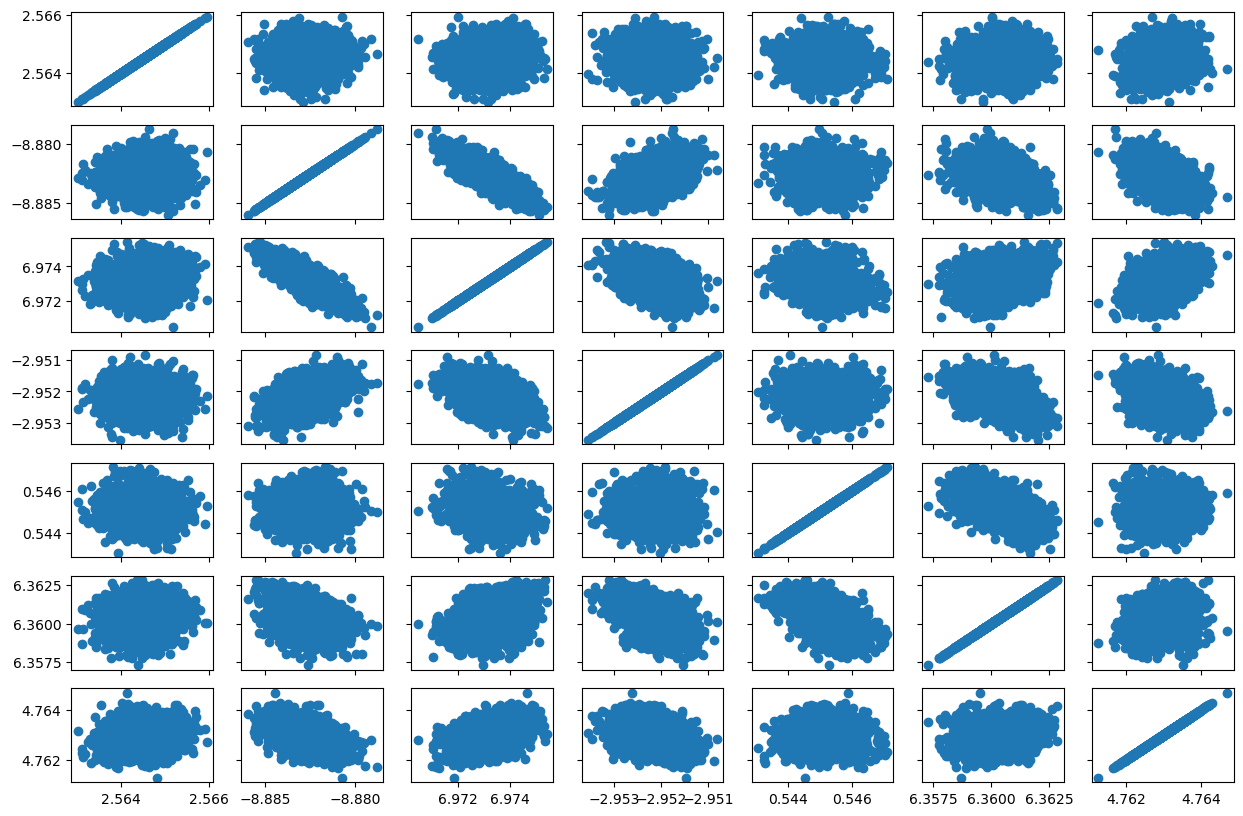

In [18]:
n_L = latents.shape[-1]
fig, axs = plt.subplots(n_L, n_L, figsize=(15, 10), sharex='col', sharey='row')
for i in range(n_L):
    for j in range(n_L):
        axs[i,j].scatter(latents[:,j], latents[:,i])
fig.savefig('7L.png', dpi=600)

In [19]:
from jax_amber2 import *
gas_fun = get_amber_gas_energy_function('Simulation/1crn_H.prmtop')

Excluding Outliers GMM - 0 RECON - 0


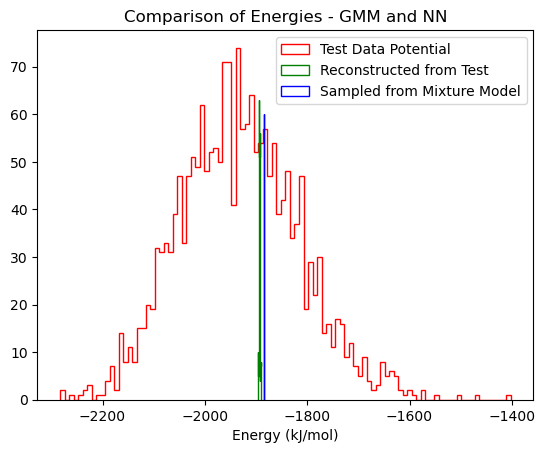

In [20]:
plt.clf()

recon_energies = gas_fun(recon)

decoded_samples = experiment.model.apply({'params': experiment.state.params}, samples, rng, method=experiment.model.decode)
sampled_energies = gas_fun(decoded_samples)

org_energies = gas_fun(experiment.test_data)

threshold = 1e3
num_excluded_gmm = len(sampled_energies) - len(sampled_energies[sampled_energies<threshold])
num_excluded_nn  = len(recon_energies) - len(recon_energies[recon_energies<threshold])
print(f'Excluding Outliers GMM - {num_excluded_gmm} RECON - {num_excluded_nn}')

_ = plt.hist(org_energies[org_energies < threshold], bins=100, histtype='step', color='r')
_ = plt.hist(recon_energies[recon_energies<threshold], bins=100, histtype='step', color='g')
_ = plt.hist(sampled_energies[sampled_energies<threshold], bins=100, histtype='step', color='b')

plt.legend(('Test Data Potential', 'Reconstructed from Test', 'Sampled from Mixture Model'))
plt.xlabel('Energy (kJ/mol)')
plt.title('Comparison of Energies - GMM and NN')
plt.show()

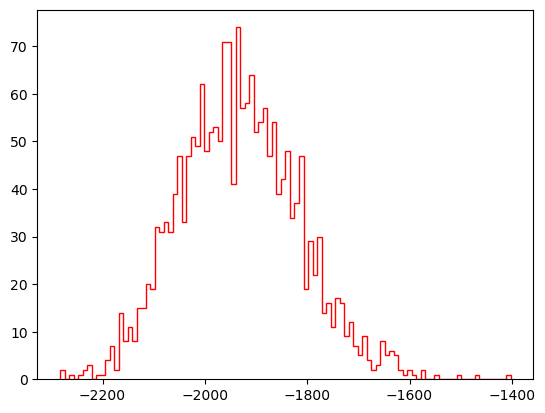

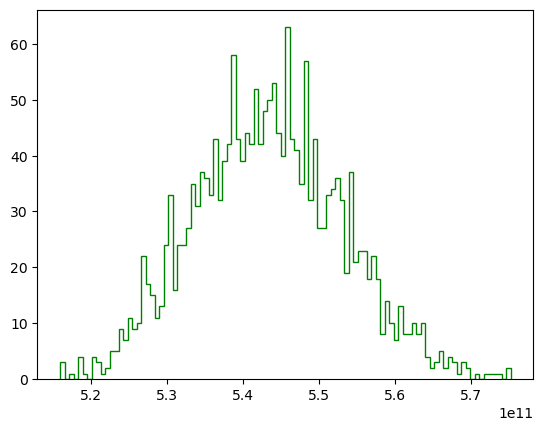

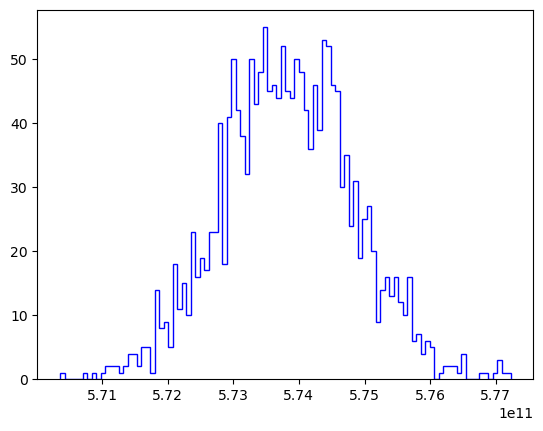

In [19]:
plt.clf()
_ = plt.hist(org_energies, bins=100, histtype='step', color='r')
plt.show()
plt.clf()
_ = plt.hist(recon_energies, bins=100, histtype='step', color='g')
plt.show()
plt.clf()
_ = plt.hist(sampled_energies, bins=100, histtype='step', color='b')
plt.show()

In [ ]:
experiment.train_summation(1e-1, 100, cutoff_epoch)
print('END TRAINING')
walltime = datetime.now() - start
print(f'Walltime per epoch was {walltime/n_epochs}')
experiment.save_loss_data()
experiment.write_model_to_ckpt()

In [ ]:
walltime = datetime.now() - start
print(f'Walltime per epoch was {walltime/n_epochs}')

In [ ]:
#Init Experiment
experiment = AutoEncoder_Experiment(json_fn)
experiment.restore_latest()
print(experiment.epoch)
experiment.train_nepochs_on_rmsd(200)
experiment.save_loss_data()

(8000, 306) (2000, 306)
### MODEL TYPE = AE_Sigmoid_Dropout ###
Sigmoid_Dropout_AutoEncoder(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    n_latents = 7
    dropout_rates = [0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE
20
epoch 20 atom_rmsd_nm 8.7902E-01 8.7902E-01 dPotEnr 1.0745E+14 1.0745E+14 Summation 8.7920E+00 8.7919E+00 L=0.0000E+00
epoch 21 atom_rmsd_nm 8.6182E-01 8.6183E-01 dPotEnr 8.3759E+13 8.3819E+13 Summation 8.6201E+00 8.6201E+00 L=0.0000E+00
epoch 22 atom_rmsd_nm 8.4481E-01 8.4481E-01 dPotEnr 5.3434E+13 5.3497E+13 Summation 8.4501E+00 8.4501E+00 L=0.0000E+00
epoch 23 atom_rmsd_nm 8.2797E-01 8.2797E-01 dPotEnr 7.4919E+12 7.4899E+12 Summation 8.2818E+00 8.2818E+00 L=0.0000E+00
epoch 24 atom_rmsd_nm 8.1135E-01 8.1135E-01 dPotEnr 1.0280E+12 1.0281E+12 Summation 8.1158E+00 8.1157E+00 L=0.0000E+00
epoch 25 atom_rmsd_nm 7.9488E-01 7.9488E-01 dPotEnr 3.0464E+12 3.0506E+12 Summation 7.9513E+00 7.9513E+00 L=0.0000E+00
epoch 26 atom_rmsd_nm 7.7859E-01 7.7

In [9]:
walltime = datetime.now() - start
print(f'Walltime per epoch was {walltime/n_epochs}')

Walltime per epoch was 0:00:20.042941


In [ ]:
# # RMSD BLOCK 2
# # Train until last 100 vals average less than predefined cutoff, always make sure we never train longer than cutoff_epoch
# begin_scaling_epoch = experiment.train_rmsd_threshold(nm_cutoff, num_move_ave, rmsd_cutoff)
# experiment.write_model_to_ckpt()
# print('END RMSD')

In [7]:
begin_scaling_epoch = experiment.epoch
print(experiment.epoch)

100


In [ ]:
# SCALE IN POTENTIAL BLOCK
end_scaling_epoch = experiment.train_scaling_potential(cutoff_epoch)
print('END SCALING POTENTIAL')
experiment.save_loss_data()
experiment.write_model_to_ckpt()

In [ ]:
experiment.train_summation(1e-1, 100, cutoff_epoch)
print('END TRAINING')
experiment.save_loss_data()
experiment.write_model_to_ckpt()
experiment.graph_losses(begin_scaling_epoch=begin_scaling_epoch, end_scaling_epoch=end_scaling_epoch)

In [ ]:
experiment.train_summation(1e-2, 100, cutoff_epoch)
print('END TRAINING')
experiment.save_loss_data()
experiment.write_model_to_ckpt()
experiment.graph_losses(begin_scaling_epoch=begin_scaling_epoch, end_scaling_epoch=end_scaling_epoch)